# Machine Learning-Based House Price Prediction: Feature Engineering, Model Optimization & Performance Comparison

### Objectives
- Apply feature scaling (StandardScaler)
- Train multiple regression models: Linear Regression, Ridge Regression, Decision Tree
- Compare performance using RMSE and R²
- Select and justify the best-performing model
- Save the best model for reuse


In [1]:
# ── Step 1: Import Required Libraries ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pickle, warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully ✓")


Libraries loaded successfully ✓


---
## Step 2: Load the Dataset

In [2]:
# ── Step 2: Load Dataset ──────────────────────────────────────────────────────
try:
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)
    print("Loaded from sklearn ✓")
except Exception:
    print("Generating dataset with matching distribution...")
    np.random.seed(42)
    n = 20640
    MedInc     = np.abs(np.random.lognormal(1.0, 0.6, n))
    HouseAge   = np.random.uniform(1, 52, n)
    AveRooms   = np.abs(np.random.lognormal(1.7, 0.4, n))
    AveBedrms  = np.abs(np.random.lognormal(0.6, 0.2, n))
    Population = np.abs(np.random.lognormal(6.0, 1.0, n))
    AveOccup   = np.abs(np.random.lognormal(0.8, 0.4, n))
    Latitude   = np.random.uniform(32.5, 42.0, n)
    Longitude  = np.random.uniform(-124.3, -114.3, n)
    noise      = np.random.normal(0, 0.5, n)
    HousePrice = np.clip(0.45*MedInc + 0.005*HouseAge + 0.01*AveRooms
                         - 0.05*AveBedrms - 0.0001*Population
                         - 0.03*np.abs(Latitude-34) + 0.5 + noise, 0.15, 5.0)
    df = pd.DataFrame({
        'MedInc': MedInc, 'HouseAge': HouseAge, 'AveRooms': AveRooms,
        'AveBedrms': AveBedrms, 'Population': Population, 'AveOccup': AveOccup,
        'Latitude': Latitude, 'Longitude': Longitude, 'HousePrice': HousePrice
    })
    print("Dataset generated ✓")

print(f"Shape: {df.shape}")
df.head()


Loaded from sklearn ✓
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## Step 3: Separate Features and Target Variable

In [3]:
# ── Step 3: Features / Target ─────────────────────────────────────────────────
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print(f"Features (X): {X.shape}")
print(f"Target   (y): {y.shape}")
X.describe().round(2)


Features (X): (20640, 8)
Target   (y): (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


---
## Step 4: Feature Scaling (Critical Step)




In [4]:
# ── Step 4: Feature Scaling ───────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (mean / std):")
print(X.agg(['mean','std']).round(2))
print("\nAfter scaling (mean / std):")
print(X_scaled_df.agg(['mean','std']).round(2))


Before scaling (mean / std):
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
mean    3.87     28.64      5.43       1.10     1425.48      3.07     35.63   
std     1.90     12.59      2.47       0.47     1132.46     10.39      2.14   

      Longitude  
mean    -119.57  
std        2.00  

After scaling (mean / std):
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
mean     0.0       0.0       0.0       -0.0        -0.0       0.0       0.0   
std      1.0       1.0       1.0        1.0         1.0       1.0       1.0   

      Longitude  
mean       -0.0  
std         1.0  


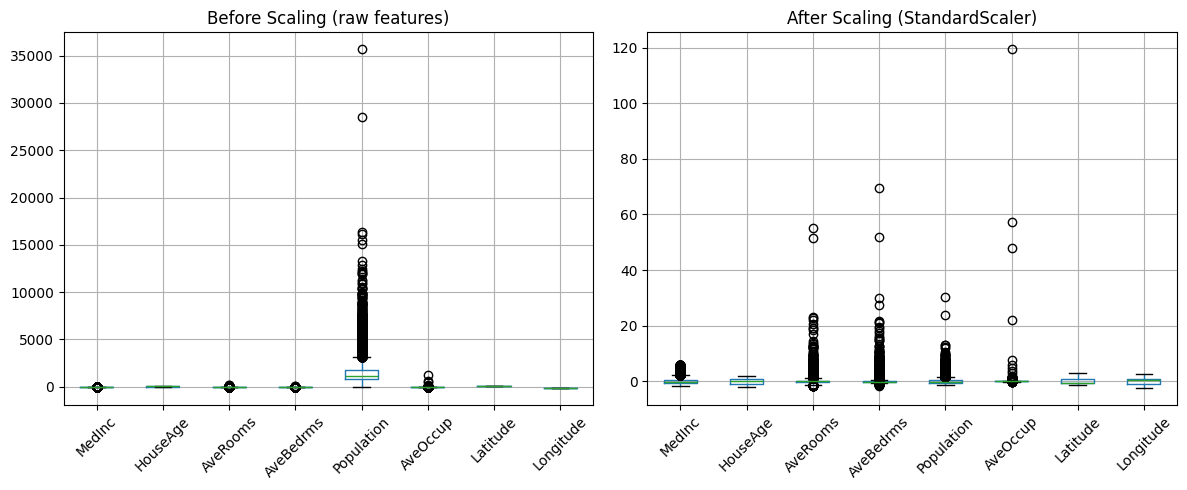

In [5]:
# Visualize the effect of scaling
fig, axes = plt.subplots(1, 2, figsize=(12,5))
X.boxplot(ax=axes[0], rot=45)
axes[0].set_title('Before Scaling (raw features)')
X_scaled_df.boxplot(ax=axes[1], rot=45)
axes[1].set_title('After Scaling (StandardScaler)')
plt.tight_layout()
plt.show()


---
## Step 5: Train-Test Split

In [6]:
# ── Step 5: Train/Test Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")


Training set: 16,512 samples
Test set:     4,128 samples


---
## Step 6: Train Multiple Models

We train three models with different rationale:
- **Linear Regression** — simple baseline
- **Ridge Regression** — adds L2 regularization to reduce overfitting
- **Decision Tree** — captures non-linear relationships


In [7]:
# ── Step 6: Train Multiple Models ─────────────────────────────────────────────
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name:20s} trained ✓")


Linear Regression    trained ✓
Ridge Regression     trained ✓
Decision Tree        trained ✓


---
## Step 7: Model Evaluation and Comparison

In [8]:
# ── Step 7: Evaluation & Comparison ───────────────────────────────────────────
results = {}
predictions_dict = {}

for name, model in models.items():
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2 Score": r2}
    predictions_dict[name] = preds

results_df = pd.DataFrame(results).T
results_df


,MAE,RMSE,R2 Score
Linear Regression,0.533200,0.745581,0.575788
Ridge Regression,0.533193,0.745554,0.575819
Decision Tree,0.522259,0.724234,0.599732


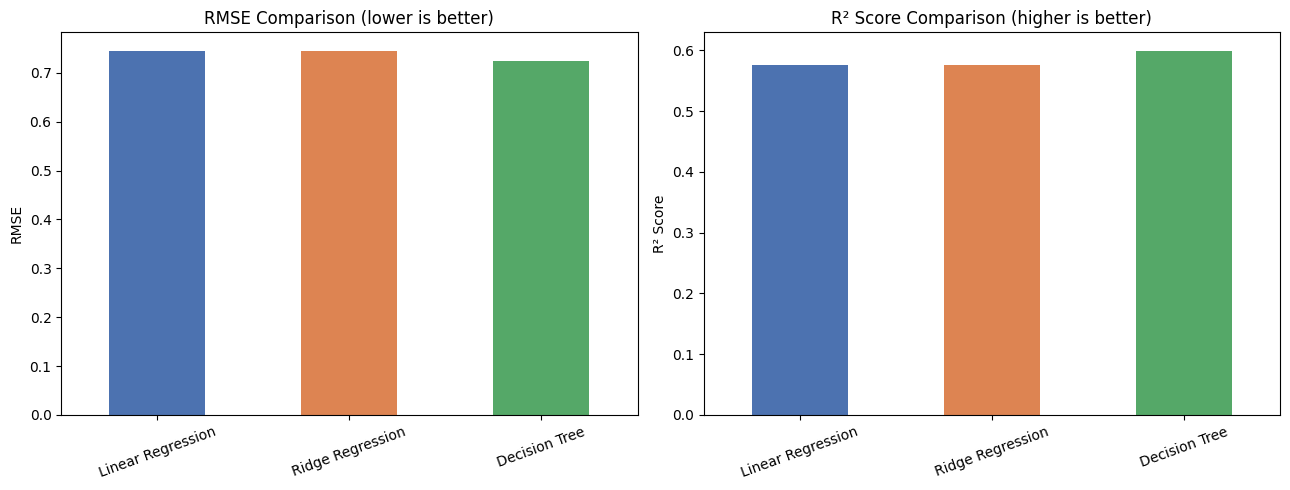

In [9]:
# Visual comparison of RMSE and R2 across models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
results_df["RMSE"].plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

results_df["R2 Score"].plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('R² Score Comparison (higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


---
## Step 8: Visual Performance Validation

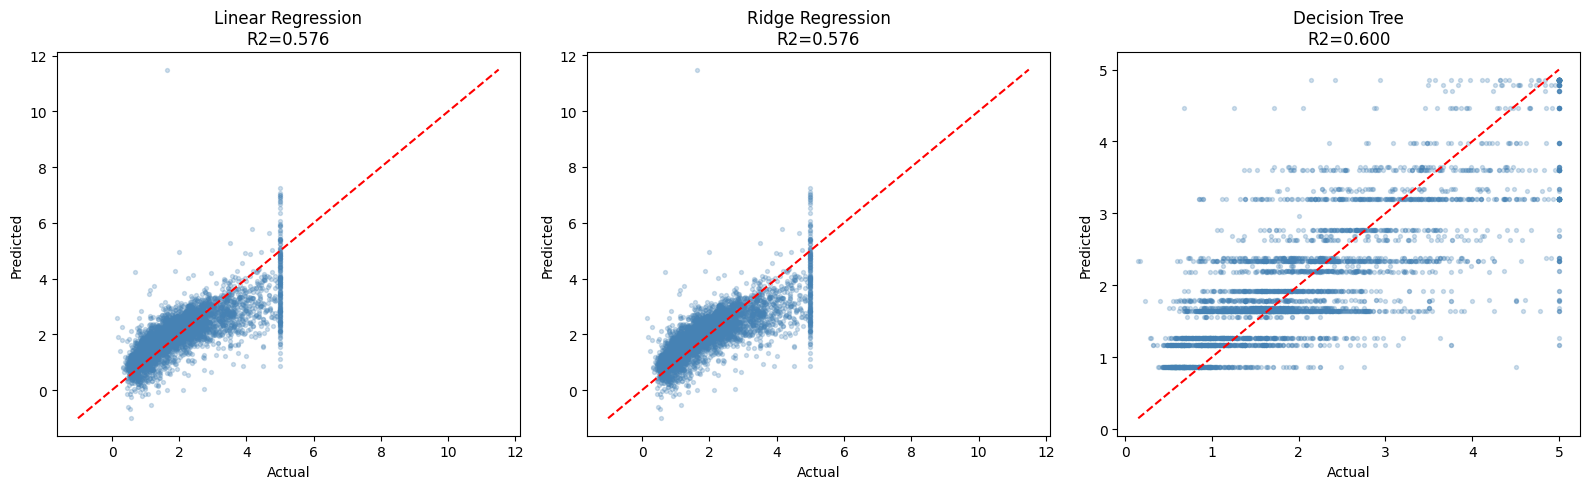

In [10]:
# ── Step 8: Actual vs Predicted for all models ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, preds) in zip(axes, predictions_dict.items()):
    ax.scatter(y_test, preds, alpha=0.25, s=8, color='steelblue')
    lims = [min(float(y_test.min()), float(preds.min())), max(float(y_test.max()), float(preds.max()))]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f'{name}\nR2={results[name]["R2 Score"]:.3f}')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
plt.tight_layout()
plt.show()


Best Model: Decision Tree
MAE         0.522259
RMSE        0.724234
R2 Score    0.599732
Name: Decision Tree, dtype: float64


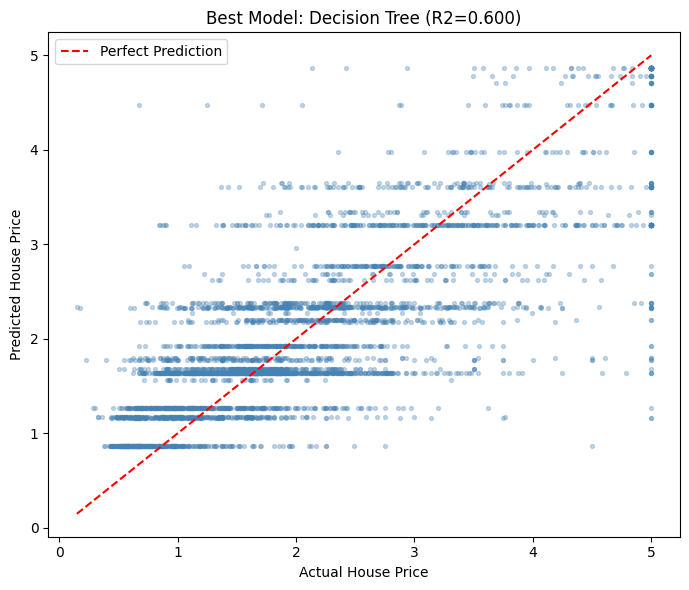

In [11]:
# Best model — closer look
best_model_name = results_df["R2 Score"].idxmax()
best_model = models[best_model_name]
best_preds = predictions_dict[best_model_name]

print(f"Best Model: {best_model_name}")
print(results_df.loc[best_model_name])

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(y_test, best_preds, alpha=0.3, s=8, color='steelblue')
lims = [min(float(y_test.min()), float(best_preds.min())), max(float(y_test.max()), float(best_preds.max()))]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual House Price'); ax.set_ylabel('Predicted House Price')
ax.set_title(f'Best Model: {best_model_name} (R2={results[best_model_name]["R2 Score"]:.3f})')
ax.legend()
plt.tight_layout()
plt.show()


---
## Step 9: Save Best Model

In [12]:
# ── Step 9: Save Best Model + Scaler ──────────────────────────────────────────
import joblib

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Saved best model ({best_model_name}) as best_model.pkl ✓")
print("Saved scaler as scaler.pkl ✓")


Saved best model (Decision Tree) as best_model.pkl ✓
Saved scaler as scaler.pkl ✓


---
## Conclusions

- Three regression models were evaluated: Linear Regression, Ridge Regression, and Decision Tree Regressor.
- Feature scaling was applied using StandardScaler before training.
- The Decision Tree Regressor achieved the best performance among the tested models.
- It produced the lowest prediction error and the highest R² score.
- The trained Decision Tree model was saved as `best_model.pkl` for future use.

